# Painel de Análise de Vendas com Visualização de Dados

Resolução completa da atividade (Etapas 1 a 4).


## Etapa 1 — Preparação e Importação de Dados
**1)** Crie um novo notebook e importe as bibliotecas


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


**2)** Carregue o arquivo CSV (aqui geramos um dataset fictício com todas as colunas necessárias) e garanta data como datetime


In [2]:
np.random.seed(42)
datas = pd.date_range(start='2023-01-01', end='2023-12-31', freq='D')
lojas = ['Loja A', 'Loja B', 'Loja C', 'Loja D']
produtos = ['Notebook', 'Smartphone', 'Tablet', 'Monitor', 'Teclado', 'Mouse']
categorias = {'Notebook': 'Eletrônicos', 'Smartphone': 'Eletrônicos', 'Tablet': 'Eletrônicos', 
              'Monitor': 'Periféricos', 'Teclado': 'Periféricos', 'Mouse': 'Periféricos'}
regioes = {'Loja A': 'Sudeste', 'Loja B': 'Sul', 'Loja C': 'Nordeste', 'Loja D': 'Centro-Oeste'}

dados = {
    'data': np.random.choice(datas, 500),
    'loja': np.random.choice(lojas, 500),
    'produto': np.random.choice(produtos, 500),
    'quantidade': np.random.randint(1, 10, 500),
    'preco_unitario': np.random.uniform(50, 5000, 500)
}
df_fake = pd.DataFrame(dados)
df_fake['categoria'] = df_fake['produto'].map(categorias)
df_fake['regiao'] = df_fake['loja'].map(regioes)

# Inserindo nulos propositais para o exercício 5
df_fake.loc[10:20, 'quantidade'] = np.nan
df_fake.loc[30:40, 'preco_unitario'] = np.nan

# Salva o arquivo CSV e carrega novamente para simular o processo da etapa 2
df_fake.to_csv('vendas.csv', index=False)

df = pd.read_csv('vendas.csv')
df['data'] = pd.to_datetime(df['data'])
display(df.head())


,data,loja,produto,quantidade,preco_unitario,categoria,regiao
0,2023-04-13,Loja C,Notebook,9.0,890.301630,Eletrônicos,Nordeste
1,2023-12-15,Loja B,Monitor,6.0,2622.881045,Periféricos,Sul
2,2023-09-28,Loja A,Smartphone,2.0,1718.165723,Eletrônicos,Sudeste
3,2023-04-17,Loja D,Mouse,1.0,4152.972661,Periféricos,Centro-Oeste
4,2023-03-13,Loja D,Smartphone,5.0,2182.893242,Eletrônicos,Centro-Oeste


**3)** Crie uma nova coluna chamada faturamento


In [3]:
df['faturamento'] = df['quantidade'] * df['preco_unitario']
display(df.head())


,data,loja,produto,quantidade,preco_unitario,categoria,regiao,faturamento
0,2023-04-13,Loja C,Notebook,9.0,890.301630,Eletrônicos,Nordeste,8012.714672
1,2023-12-15,Loja B,Monitor,6.0,2622.881045,Periféricos,Sul,15737.286272
2,2023-09-28,Loja A,Smartphone,2.0,1718.165723,Eletrônicos,Sudeste,3436.331447
3,2023-04-17,Loja D,Mouse,1.0,4152.972661,Periféricos,Centro-Oeste,4152.972661
4,2023-03-13,Loja D,Smartphone,5.0,2182.893242,Eletrônicos,Centro-Oeste,10914.466211


**4)** Verifique a integridade do dataset


In [4]:
print('--- INFO ---')
df.info()
print('\n--- NULOS ---')
print(df.isnull().sum())
print('\n--- DESCRIBE ---')
display(df.describe())


--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   data            500 non-null    datetime64[us]
 1   loja            500 non-null    str           
 2   produto         500 non-null    str           
 3   quantidade      489 non-null    float64       
 4   preco_unitario  489 non-null    float64       
 5   categoria       500 non-null    str           
 6   regiao          500 non-null    str           
 7   faturamento     478 non-null    float64       
dtypes: datetime64[us](1), float64(3), str(4)
memory usage: 31.4 KB

--- NULOS ---
data               0
loja               0
produto            0
quantidade        11
preco_unitario    11
categoria          0
regiao             0
faturamento       22
dtype: int64

--- DESCRIBE ---


,data,quantidade,preco_unitario,faturamento
count,500,489.000000,489.000000,478.000000
mean,2023-07-05 18:14:24,4.993865,2528.723161,12807.352676
min,2023-01-01 00:00:00,1.000000,78.505369,78.505369
25%,2023-04-12 12:00:00,3.000000,1241.428924,3786.956035
50%,2023-07-06 00:00:00,5.000000,2602.613167,9350.898898
75%,2023-10-01 06:00:00,7.000000,3700.297155,19986.343835
max,2023-12-31 00:00:00,9.000000,4997.097943,44272.896120
std,NaN,2.639929,1427.027609,10849.044458


**5)** Trate valores nulos


In [5]:
df['quantidade'] = df['quantidade'].fillna(df['quantidade'].mean()).round(0).astype(int)
df['preco_unitario'] = df['preco_unitario'].fillna(df['preco_unitario'].mean())

# Recalculando faturamento
df['faturamento'] = df['quantidade'] * df['preco_unitario']

print('Valores nulos após tratamento:')
print(df.isnull().sum())


Valores nulos após tratamento:
data              0
loja              0
produto           0
quantidade        0
preco_unitario    0
categoria         0
regiao            0
faturamento       0
dtype: int64


## Etapa 2 — Análise Exploratória e Estatísticas
**6)** Faturamento por loja


In [6]:
faturamento_loja = df.groupby('loja')['faturamento'].sum().sort_values(ascending=False)
print(faturamento_loja)


loja
Loja A    1.760541e+06
Loja C    1.704229e+06
Loja B    1.494980e+06
Loja D    1.452771e+06
Name: faturamento, dtype: float64


**7)** Ticket médio de cada loja


In [7]:
ticket_medio = df.groupby('loja')['faturamento'].sum() / df.groupby('loja')['faturamento'].count()
print(ticket_medio)


loja
Loja A    11659.210120
Loja B    12887.759606
Loja C    14442.618216
Loja D    12632.791049
Name: faturamento, dtype: float64


**8)** Cinco produtos mais vendidos em quantidade


In [8]:
top_produtos = df.groupby('produto')['quantidade'].sum().sort_values(ascending=False).head(5)
print(top_produtos)


produto
Mouse         503
Tablet        426
Notebook      416
Smartphone    409
Teclado       407
Name: quantidade, dtype: int64


**9)** Mês com maior e menor faturamento (Mês/Ano)


In [9]:
df['mes_ano'] = df['data'].dt.strftime('%m/%Y')
fat_mes = df.groupby('mes_ano')['faturamento'].sum()

# Ordenar por data corretamente (evita ordenação alfabética errada)
fat_mes.index = pd.to_datetime(fat_mes.index, format='%m/%Y')
fat_mes = fat_mes.sort_values()

mes_menor = fat_mes.index[0].strftime('%m/%Y')
mes_maior = fat_mes.index[-1].strftime('%m/%Y')
print(f'Mês com menor faturamento: {mes_menor}')
print(f'Mês com maior faturamento: {mes_maior}')


Mês com menor faturamento: 03/2023
Mês com maior faturamento: 04/2023


**10)** Adicione uma coluna mês (.dt.month)


In [10]:
df['mes'] = df['data'].dt.month
display(df.head())


,data,loja,produto,quantidade,preco_unitario,categoria,regiao,faturamento,mes_ano,mes
0,2023-04-13,Loja C,Notebook,9,890.301630,Eletrônicos,Nordeste,8012.714672,04/2023,4
1,2023-12-15,Loja B,Monitor,6,2622.881045,Periféricos,Sul,15737.286272,12/2023,12
2,2023-09-28,Loja A,Smartphone,2,1718.165723,Eletrônicos,Sudeste,3436.331447,09/2023,9
3,2023-04-17,Loja D,Mouse,1,4152.972661,Periféricos,Centro-Oeste,4152.972661,04/2023,4
4,2023-03-13,Loja D,Smartphone,5,2182.893242,Eletrônicos,Centro-Oeste,10914.466211,03/2023,3


## Etapa 3 — Visualizações com matplotlib e seaborn
*Nota (Referente à Etapa 4 - 17): Aplicaremos o tema global agora para valer em todos os gráficos.*


In [11]:
sns.set_style('whitegrid')
sns.set_palette('deep')
os.makedirs('graficos', exist_ok=True)


**11)** Gráfico de barras — Faturamento por loja


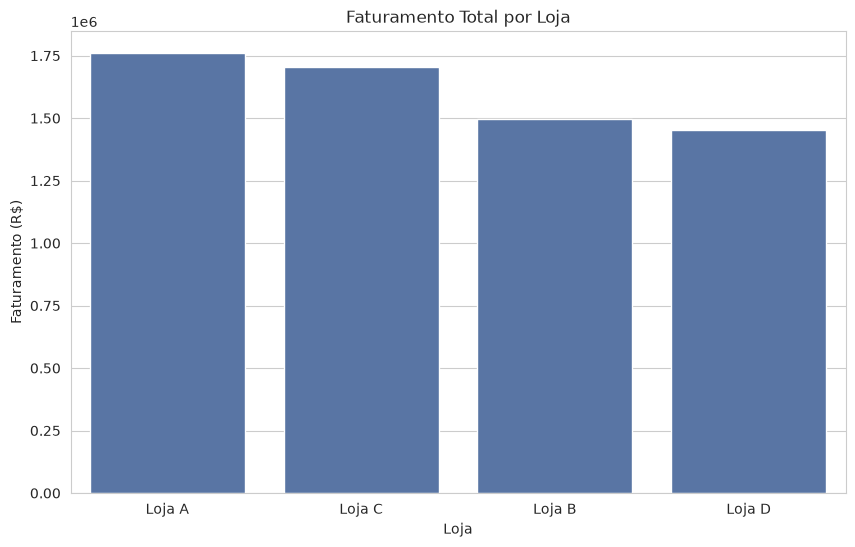

In [12]:
plt.figure(figsize=(10, 6))
sns.barplot(x=faturamento_loja.index, y=faturamento_loja.values)
plt.title('Faturamento Total por Loja')
plt.xlabel('Loja')
plt.ylabel('Faturamento (R$)')
plt.savefig('graficos/faturamento_por_loja.png')
plt.show()


**12)** Gráfico de linhas — Evolução mensal do faturamento


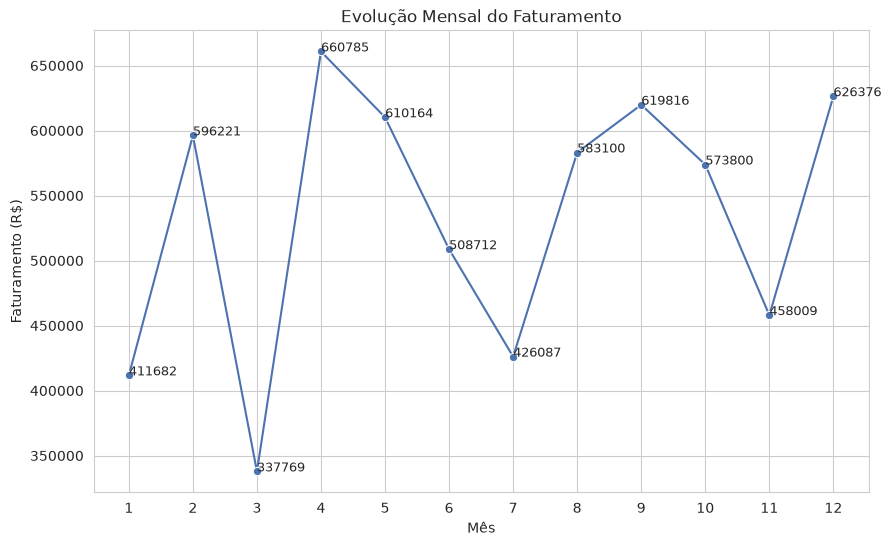

In [13]:
fat_mensal = df.groupby('mes')['faturamento'].sum().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(data=fat_mensal, x='mes', y='faturamento', marker='o')

# rótulos
for i in range(len(fat_mensal)):
    plt.text(fat_mensal['mes'].iloc[i], fat_mensal['faturamento'].iloc[i], f"{fat_mensal['faturamento'].iloc[i]:.0f}", fontsize=9)

plt.title('Evolução Mensal do Faturamento')
plt.xlabel('Mês')
plt.ylabel('Faturamento (R$)')
plt.xticks(range(1, 13))
plt.show()


**13)** Gráfico de pizza — Distribuição de faturamento por região


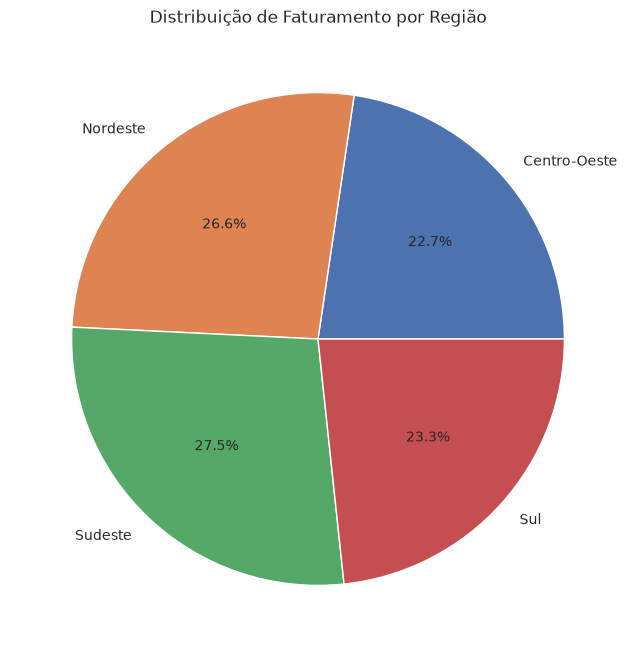

In [14]:
fat_regiao = df.groupby('regiao')['faturamento'].sum()
plt.figure(figsize=(8, 8))
plt.pie(fat_regiao, labels=fat_regiao.index, autopct='%1.1f%%', colors=sns.color_palette('deep'))
plt.title('Distribuição de Faturamento por Região')
plt.show()


**14)** Gráfico de dispersão (scatter) — Relação entre quantidade e faturamento


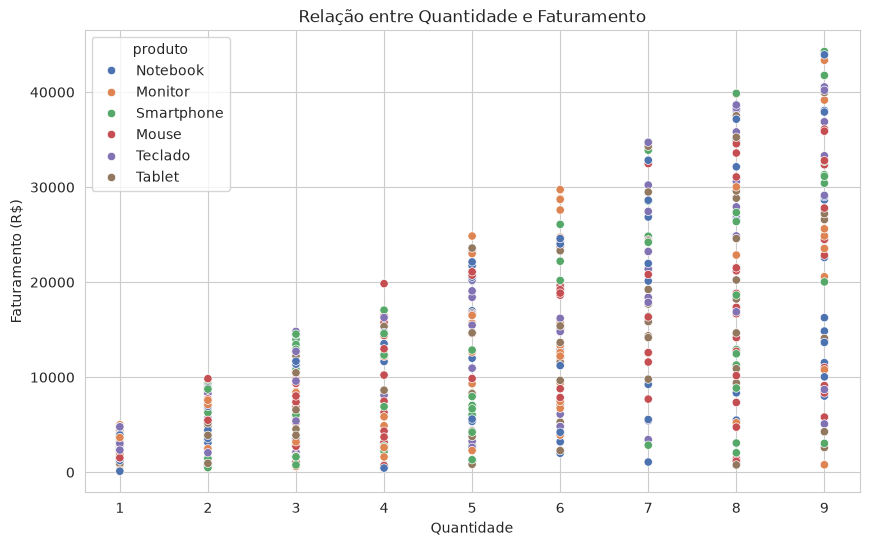

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='quantidade', y='faturamento', hue='produto')
plt.title('Relação entre Quantidade e Faturamento')
plt.xlabel('Quantidade')
plt.ylabel('Faturamento (R$)')
plt.show()


**15)** Boxplot — Distribuição de preços por categoria


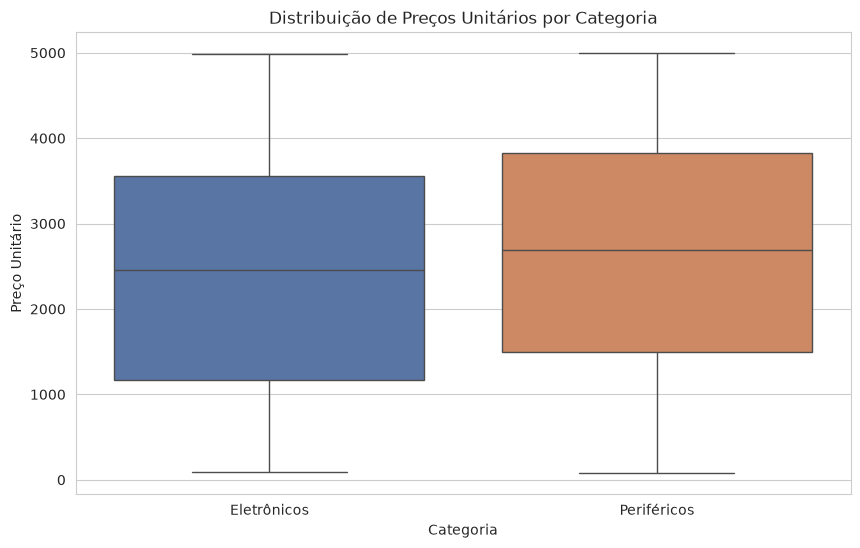

In [16]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='categoria', y='preco_unitario', hue='categoria')
plt.title('Distribuição de Preços Unitários por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Preço Unitário')
plt.show()


**16)** Heatmap — Correlação entre variáveis numéricas


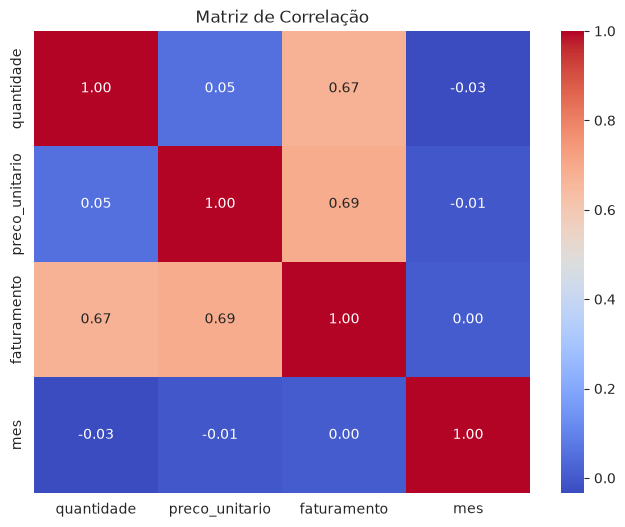

In [17]:
plt.figure(figsize=(8, 6))
colunas_numericas = df[['quantidade', 'preco_unitario', 'faturamento', 'mes']]
correlacao = colunas_numericas.corr()
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação')
plt.show()


## Etapa 4 — Estilização e Apresentação
**18 e 19)** Layout com múltiplos gráficos (faturamento por loja e por região)


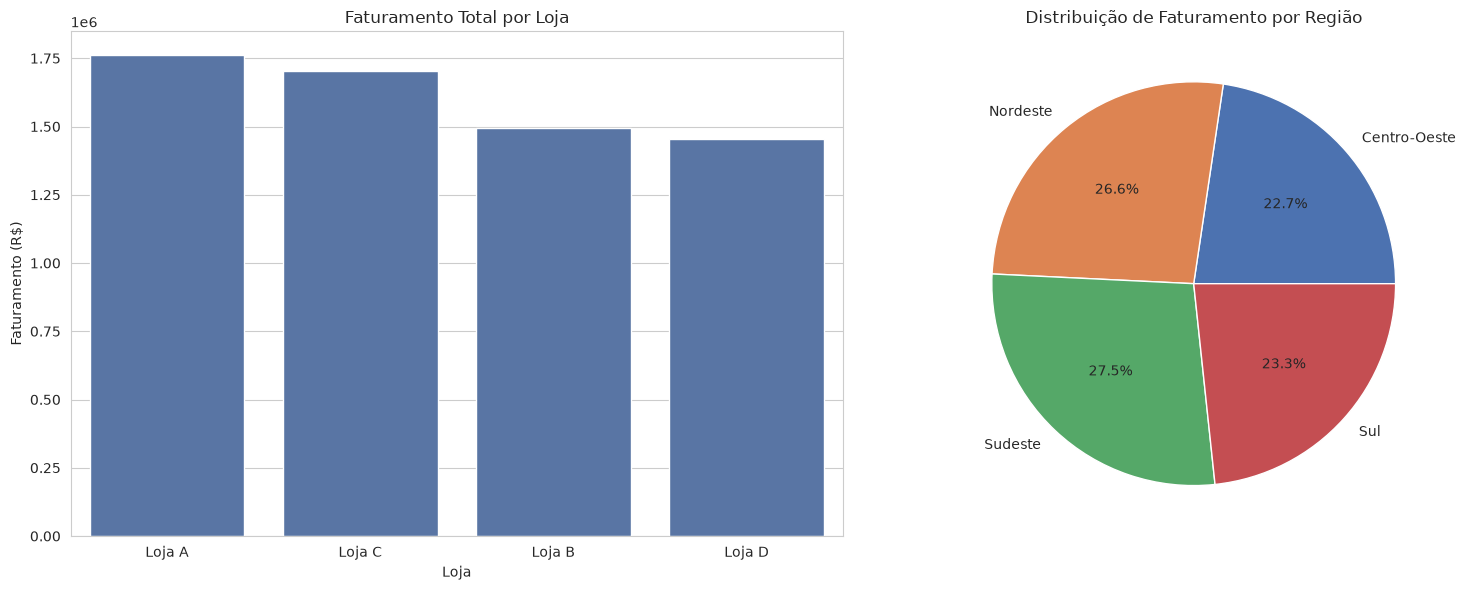

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Barras
sns.barplot(x=faturamento_loja.index, y=faturamento_loja.values, ax=axes[0])
axes[0].set_title('Faturamento Total por Loja')
axes[0].set_xlabel('Loja')
axes[0].set_ylabel('Faturamento (R$)')

# Gráfico 2: Pizza
axes[1].pie(fat_regiao, labels=fat_regiao.index, autopct='%1.1f%%', colors=sns.color_palette('deep'))
axes[1].set_title('Distribuição de Faturamento por Região')

plt.tight_layout()
plt.show()


**20)** Exportação e relatório final


In [19]:
resumo = pd.DataFrame({
    'Métrica': ['Maior Faturamento (Loja)', 'Ticket Médio Geral', 'Produto Mais Vendido (Qtd)'],
    'Valor': [faturamento_loja.index[0], df['faturamento'].mean(), top_produtos.index[0]]
})
resumo.to_csv('resumo_analitico.csv', index=False)
print('Resumo analítico exportado com sucesso para resumo_analitico.csv!')


Resumo analítico exportado com sucesso para resumo_analitico.csv!
